<a href="https://colab.research.google.com/github/jothigup/weather-prediction-RDU/blob/daniel-linear-regression/yaari_daniel_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
ACTUAL_PATH  = 'RDU_ACTUAL_HISTORICAL.csv'
FUTURE_PATH  = 'FORECAST_FUTURE.csv'
RUNS_CACHE   = 'gfs_runs_18z.csv'        # downloaded runs are cached here

CUTOFF       = pd.Timestamp('2026-09-17 00:00')   # no data at or after this (Eastern)
TARGET_START = pd.Timestamp('2026-09-17 00:00')
TARGET_END   = pd.Timestamp('2026-09-30 23:00')

RUN_HOUR_UTC = 18                         # FORECAST_FUTURE.csv starts 2pm EDT = 18Z
FIRST_RUN    = '2026-04-03'
LAST_RUN     = '2026-09-16'               # the Sep 16 18Z run is the one we forecast from
MAX_LEAD_DAYS = 15                        # Sep 30 11pm is 345 h after the run -> lead day 15
CLIMO_YEARS  = (2018, 2025)               # climatology never sees 2026

LAT, LON = 35.88, -78.79

# 'api'  = use the Sep 16 18Z run from the same API/model as training (recommended)
# 'csv'  = use FORECAST_FUTURE.csv
FUTURE_SOURCE = 'api'

def rmse(a, b):
    return float(np.sqrt(mean_squared_error(a, b)))

## Actual RDU temperature (cut off at Sep 17 12am)

In [ ]:
actual = pd.read_csv(ACTUAL_PATH, low_memory=False)
actual = actual.rename(columns={'valid': 'time'})
actual['time'] = pd.to_datetime(actual['time'])
actual['tmpf'] = pd.to_numeric(actual['tmpf'], errors='coerce')
actual = actual.dropna(subset=['tmpf'])

# The 12:51 observation is labelled 1:00. If the grader labels it 12:00
# instead, change .dt.round('h') to .dt.floor('h') here and nowhere else.
actual['time'] = actual['time'].dt.round('h')

actual_hourly = (actual.groupby('time', as_index=False)['tmpf'].mean()
                       .rename(columns={'tmpf': 'actual_temp'}))

# PROJECT RULE: nothing from Sep 17 12am onward
actual_hourly = actual_hourly[actual_hourly['time'] < CUTOFF].reset_index(drop=True)

print(actual_hourly['time'].min(), '->', actual_hourly['time'].max())
assert actual_hourly['time'].max() < CUTOFF

2018-01-01 01:00:00 -> 2026-09-16 23:00:00


## Climatology (the "normal/average" temperature for each hour and date)

I want to create a small linear regression on yearly and daily trends only fitted on 2018–2025 to be used as a baseline calc.

In [ ]:
def climo_design(times):
    times = pd.DatetimeIndex(times)
    doy = 2 * np.pi * times.dayofyear.values / 365.25
    hr  = 2 * np.pi * times.hour.values / 24
    year_terms = [np.ones(len(times)), np.sin(doy), np.cos(doy), np.sin(2*doy), np.cos(2*doy)] # X transform (daily on yearly cycle)
    day_terms  = [np.ones(len(times)), np.sin(hr),  np.cos(hr),  np.sin(2*hr),  np.cos(2*hr)] # X transform (hourly on daily cycle)

    # need to find interactions between season and time of day
    cols = [y * d for y in year_terms for d in day_terms]
    return np.column_stack(cols[1:]) #combined interactions - need all combos

climo_data = actual_hourly[actual_hourly['time'].dt.year.between(*CLIMO_YEARS)] # Historical temperature (°F) from '18 -'25
climo_model = LinearRegression().fit(climo_design(climo_data['time']), climo_data['actual_temp'])

def climo(times):
    return climo_model.predict(climo_design(times))

print('Climatology fit RMSE:', round(rmse(climo_data['actual_temp'], climo(climo_data['time'])), 2), '°F')

Climatology fit RMSE: 8.48 °F
Normal for Sep 17 3pm: 82.4 | Sep 30 6am: 60.8


## Download one 18Z GFS run per day

In [ ]:
API_URL = 'https://single-runs-api.open-meteo.com/v1/forecast'
RENAME = {'temperature_2m': 'forecast_temp', 'precipitation': 'precipitation',
          'cloud_cover': 'cloud_cover', 'wind_speed_10m': 'wind_speed',
          'wind_direction_10m': 'wind_direction'}

def fetch_run(run_time):
    params = {'latitude': LAT, 'longitude': LON,
              'run': run_time.strftime('%Y-%m-%dT%H:%M'),
              'hourly': list(RENAME.keys()),
              'models': 'gfs_global', 'forecast_days': 16,
              'temperature_unit': 'fahrenheit', 'wind_speed_unit': 'mph',
              'precipitation_unit': 'inch', 'timezone': 'GMT'}
    r = requests.get(API_URL, params=params, timeout=30)
    r.raise_for_status()
    out = pd.DataFrame(r.json()['hourly']).rename(columns=RENAME)
    out['time'] = pd.to_datetime(out['time'])
    out['run_time'] = run_time
    return out

run_times = pd.date_range(FIRST_RUN, LAST_RUN, freq='D') + pd.Timedelta(hours=RUN_HOUR_UTC)

if os.path.exists(RUNS_CACHE):
    gfs = pd.read_csv(RUNS_CACHE, parse_dates=['time', 'run_time'])
    print('Loaded cache:', RUNS_CACHE)
else:
    all_runs, failed = [], []
    for rt in run_times:
        try:
            all_runs.append(fetch_run(rt))
        except Exception as e:
            failed.append((rt, str(e)[:80]))
        time.sleep(0.1)
    print('Successful runs:', len(all_runs), '| Failed:', len(failed), failed[:3])
    gfs = pd.concat([d for d in all_runs if d['forecast_temp'].notna().any()], ignore_index=True)
    gfs.to_csv(RUNS_CACHE, index=False)

print(gfs.shape, '| runs:', gfs['run_time'].nunique(),
      '|', gfs['run_time'].min(), '->', gfs['run_time'].max())

Successful runs: 166 | Failed: 1 [(Timestamp('2026-06-10 18:00:00'), '400 Client Error: Bad Request for url: https://single-runs-api.open-meteo.com/v1')]
(63744, 7) | runs: 166 | 2026-04-03 18:00:00 -> 2026-09-16 18:00:00


## Features

In [ ]:
def add_features(d):
    """d needs: time (Eastern), lead_hours, forecast_temp, precipitation,
    cloud_cover, wind_speed, wind_direction."""
    d = d.copy()
    d['lead_day'] = (d['lead_hours'] // 24).astype(int) + 1
    d['precipitation'] = d['precipitation'].fillna(0)
    d['climo'] = climo(d['time'])
    d['fc_anom'] = d['forecast_temp'] - d['climo']
    wd = np.deg2rad(d['wind_direction'])
    d['wind_sin'], d['wind_cos'] = np.sin(wd), np.cos(wd)
    hr = 2 * np.pi * d['time'].dt.hour / 24
    d['hour_sin'],  d['hour_cos']  = np.sin(hr),   np.cos(hr)
    d['hour_sin2'], d['hour_cos2'] = np.sin(2*hr), np.cos(2*hr)
    return d

FEATURES = ['fc_anom', 'cloud_cover', 'precipitation', 'wind_speed',
            'wind_sin', 'wind_cos', 'hour_sin', 'hour_cos', 'hour_sin2', 'hour_cos2']

g = gfs.copy()
g['lead_hours'] = (g['time'] - g['run_time']).dt.total_seconds() / 3600
g = g[(g['lead_hours'] >= 0) & (g['lead_hours'] < MAX_LEAD_DAYS * 24)]

g['time'] = (g['time'].dt.tz_localize('UTC').dt.tz_convert('America/New_York').dt.tz_localize(None))

g = add_features(g).dropna(subset=FEATURES)

future_run_time = pd.Timestamp(LAST_RUN) + pd.Timedelta(hours=RUN_HOUR_UTC)
api_future = g[g['run_time'] == future_run_time].copy()

model_df = g.merge(actual_hourly, on='time', how='inner')
model_df['target_anom'] = model_df['actual_temp'] - model_df['climo']
assert model_df['time'].max() < CUTOFF

print(model_df.shape)
print(model_df.groupby('lead_day').size().to_string())

(56774, 19)
lead_day
1     3798
2     3940
3     3916
4     3892
5     3868
6     3844
7     3820
8     3796
9     3772
10    3748
11    3724
12    3700
13    3676
14    3652
15    3628


## Model One: one linear regression (on a per lead day basis)

`actual anomaly = a + b * GFS anomaly + (cloud, rain, wind, hour-of-day terms)`

Fitting it separately for each lead day lets `b` fall toward 0 at long leads, which means
"trust the normal more, trust GFS less".

In [ ]:
def fit_models(train):
    return {day: LinearRegression().fit(grp[FEATURES], grp['target_anom'])
            for day, grp in train.groupby('lead_day')}

def predict(models, d):
    pred = pd.Series(np.nan, index=d.index)
    for day, grp in d.groupby('lead_day'):
        if day in models:
            pred.loc[grp.index] = models[day].predict(grp[FEATURES]) + grp['climo']
    return pred

## Validation: rolling-origin backtest

In [ ]:
N_FOLDS, RUNS_PER_FOLD = 4, 20
runs = np.sort(model_df['run_time'].unique())
purge = pd.Timedelta(days=MAX_LEAD_DAYS)

fold_rows, scored = [], []
for k in range(N_FOLDS):
    hi = len(runs) - (N_FOLDS - 1 - k) * RUNS_PER_FOLD
    test_runs = runs[hi - RUNS_PER_FOLD:hi]
    train = model_df[model_df['run_time'] <= test_runs[0] - purge]
    test  = model_df[model_df['run_time'].isin(test_runs)].copy()
    test['lr_pred'] = predict(fit_models(train), test)
    test = test.dropna(subset=['lr_pred'])
    test['fold'] = k + 1
    scored.append(test)
    fold_rows.append({'fold': k + 1,
                      'train_runs': train['run_time'].nunique(),
                      'test_runs': f"{pd.Timestamp(test_runs[0]).date()} -> {pd.Timestamp(test_runs[-1]).date()}",
                      'raw_GFS': rmse(test['actual_temp'], test['forecast_temp']),
                      'climatology': rmse(test['actual_temp'], test['climo']),
                      'linear_reg': rmse(test['actual_temp'], test['lr_pred'])})

scored = pd.concat(scored)
fold_table = pd.DataFrame(fold_rows).round(3)
print(fold_table.to_string(index=False))
print('\nAll folds pooled  | raw GFS: %.3f | climatology: %.3f | linear regression: %.3f'
      % (rmse(scored['actual_temp'], scored['forecast_temp']),
         rmse(scored['actual_temp'], scored['climo']),
         rmse(scored['actual_temp'], scored['lr_pred'])))

 fold  train_runs                test_runs  raw_GFS  climatology  linear_reg
    1          72 2026-06-29 -> 2026-07-18    6.605        5.980       6.368
    2          92 2026-07-19 -> 2026-08-07    5.751        4.416       4.367
    3         112 2026-08-08 -> 2026-08-27    6.357        5.333       5.073
    4         132 2026-08-28 -> 2026-09-16    5.719        6.529       4.365

All folds pooled  | raw GFS: 6.161 | climatology: 5.516 | linear regression: 5.181


          raw_GFS  climatology  linear_reg
lead_day                                  
1           3.521        5.583       3.460
2           4.042        5.658       4.001
3           4.445        5.678       4.173
4           4.804        5.660       4.460
5           4.793        5.592       4.358
6           5.083        5.481       4.906
7           6.087        5.378       5.466
8           6.137        5.382       5.372
9           6.575        5.403       5.515
10          7.213        5.435       5.884
11          7.164        5.469       6.505
12          7.033        5.454       5.546
13          7.975        5.474       5.644
14          8.018        5.510       6.471
15          8.032        5.521       5.448


/tmp/ipykernel_4968/3791844162.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_lead = scored.groupby('lead_day').apply(lambda t: pd.Series({


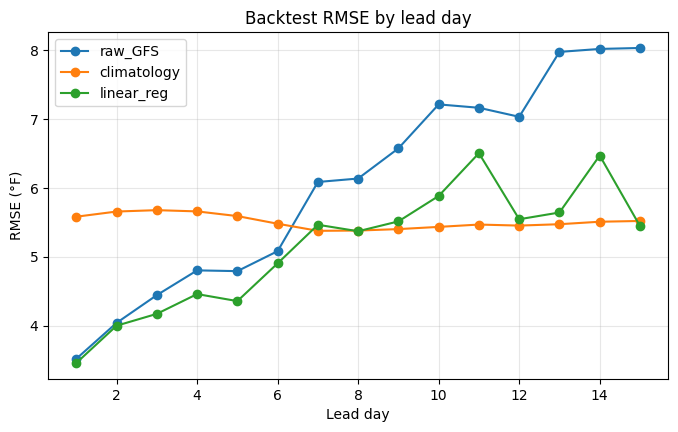

In [ ]:
by_lead = scored.groupby('lead_day').apply(lambda t: pd.Series({
    'raw_GFS': rmse(t['actual_temp'], t['forecast_temp']),
    'climatology': rmse(t['actual_temp'], t['climo']),
    'linear_reg': rmse(t['actual_temp'], t['lr_pred'])})).round(3)
print(by_lead.to_string())

by_lead.plot(marker='o', figsize=(8, 4.5))
plt.xlabel('Lead day'); plt.ylabel('RMSE (°F)')
plt.title('Backtest RMSE by lead day'); plt.grid(alpha=0.3); plt.show()

## Final model with fitted betas

In [ ]:
final_models = fit_models(model_df)

weights = pd.Series({day: m.coef_[FEATURES.index('fc_anom')] for day, m in final_models.items()})
print('Weight on the GFS anomaly by lead day:')
print(weights.round(2).to_string())

Weight on the GFS anomaly by lead day:
1     0.92
2     0.88
3     0.82
4     0.83
5     0.74
6     0.69
7     0.61
8     0.57
9     0.46
10    0.35
11    0.32
12    0.34
13    0.22
14    0.12
15    0.10


## 9. LR Testing: Sep 17 – Sep 30

In [ ]:
# FORECAST_FUTURE.csv: one run, first row is the run start (2pm EDT = 18Z)
csv_future = pd.read_csv(FUTURE_PATH, skiprows=3)
csv_future = csv_future.rename(columns={
    'temperature_2m (°F)': 'forecast_temp', 'precipitation (inch)': 'precipitation',
    'cloud_cover (%)': 'cloud_cover', 'wind_speed_10m (mp/h)': 'wind_speed',
    'wind_direction_10m (°)': 'wind_direction'})
csv_future['time'] = pd.to_datetime(csv_future['time'])
csv_future['lead_hours'] = (csv_future['time'] - csv_future['time'].min()).dt.total_seconds() / 3600
csv_future = add_features(csv_future)

# Is the CSV the same forecast as the API run the model was trained on?
if len(api_future):
    both = api_future.merge(csv_future, on='time', suffixes=('_api', '_csv'))
    diff = (both['forecast_temp_api'] - both['forecast_temp_csv']).abs()
    print('API run vs FORECAST_FUTURE.csv temperature: mean |diff| = %.2f°F, max = %.2f°F'
          % (diff.mean(), diff.max()))

future = api_future if (FUTURE_SOURCE == 'api' and len(api_future)) else csv_future
print('Forecasting from:', 'API run ' + str(future_run_time) + 'Z' if future is api_future else FUTURE_PATH)

future = future[(future['time'] >= TARGET_START) & (future['time'] <= TARGET_END)].copy()
future['predicted_temp'] = predict(final_models, future)

assert len(future) == 336, f'expected 336 target hours, got {len(future)}'
assert future['predicted_temp'].notna().all(), 'some target hours have no prediction'

out = future[['time', 'forecast_temp', 'climo', 'predicted_temp']].rename(
    columns={'forecast_temp': 'raw_gfs_temp', 'climo': 'climatology_temp'})
out[out.columns[1:]] = out[out.columns[1:]].round(2)
out.to_csv('lr_predictions_sep17_30.csv', index=False)
print(out.head()); print(out.tail())

API run vs FORECAST_FUTURE.csv temperature: mean |diff| = 0.00°F, max = 0.00°F
Forecasting from: API run 2026-09-16 18:00:00Z
                     time  raw_gfs_temp  climatology_temp  predicted_temp
63370 2026-09-17 00:00:00          70.6             68.63           72.55
63371 2026-09-17 01:00:00          69.5             67.90           71.26
63372 2026-09-17 02:00:00          68.0             67.17           69.68
63373 2026-09-17 03:00:00          66.8             66.41           68.43
63374 2026-09-17 04:00:00          65.9             65.69           67.50
                     time  raw_gfs_temp  climatology_temp  predicted_temp
63701 2026-09-30 19:00:00          69.2             72.00           73.66
63702 2026-09-30 20:00:00          68.9             69.78           71.63
63703 2026-09-30 21:00:00          68.8             67.89           69.81
63704 2026-09-30 22:00:00          68.8             66.44           68.30
63705 2026-09-30 23:00:00          68.6             65.40   

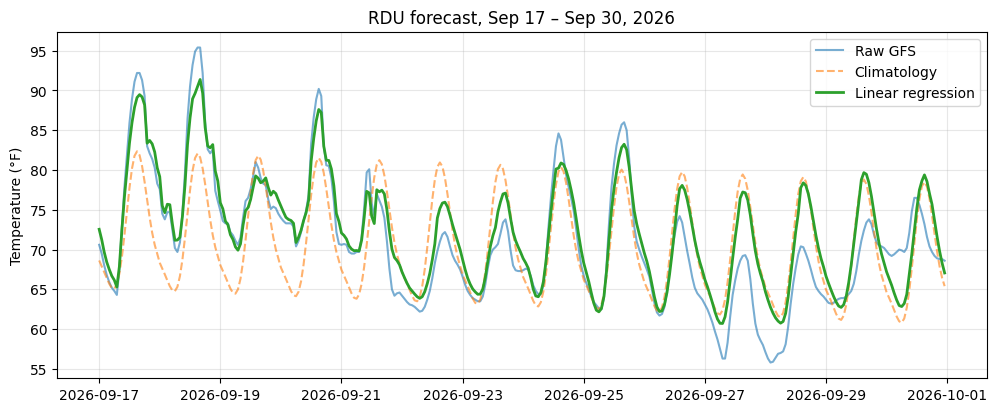

In [ ]:
plt.figure(figsize=(12, 4.5))
plt.plot(out['time'], out['raw_gfs_temp'], label='Raw GFS', alpha=0.6)
plt.plot(out['time'], out['climatology_temp'], label='Climatology', alpha=0.6, linestyle='--')
plt.plot(out['time'], out['predicted_temp'], label='Linear regression', linewidth=2)
plt.ylabel('Temperature (°F)'); plt.title('RDU forecast, Sep 17 – Sep 30, 2026')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## Second model: random forest


In [ ]:
from sklearn.ensemble import RandomForestRegressor

RF_FEATURES = FEATURES + ['lead_hours']

def make_rf(min_samples_leaf):
    return RandomForestRegressor(n_estimators=150, min_samples_leaf=min_samples_leaf,
                                 max_features=0.5, n_jobs=-1, random_state=0)

def backtest_folds():
    for k in range(N_FOLDS):
        hi = len(runs) - (N_FOLDS - 1 - k) * RUNS_PER_FOLD
        test_runs = runs[hi - RUNS_PER_FOLD:hi]
        train = model_df[model_df['run_time'] <= test_runs[0] - purge]
        test  = model_df[model_df['run_time'].isin(test_runs)]
        yield k + 1, train, test

### Tune leaf size on the backtest (Validation)

In [ ]:
LEAF_OPTIONS = [5, 25, 100]
rf_preds = {}
for leaf in LEAF_OPTIONS:
    p = pd.Series(np.nan, index=model_df.index)
    for k, train, test in backtest_folds():
        rf = make_rf(leaf).fit(train[RF_FEATURES], train['target_anom'])
        p.loc[test.index] = rf.predict(test[RF_FEATURES]) + test['climo']
    rf_preds[leaf] = p
    print('min_samples_leaf = %-4d backtest RMSE = %.3f°F'
          % (leaf, rmse(scored['actual_temp'], p.loc[scored.index])))

BEST_LEAF = min(LEAF_OPTIONS, key=lambda l: rmse(scored['actual_temp'], rf_preds[l].loc[scored.index]))
scored['rf_pred'] = rf_preds[BEST_LEAF].loc[scored.index]
print('Best:', BEST_LEAF)

min_samples_leaf = 5    backtest RMSE = 5.164°F
min_samples_leaf = 25   backtest RMSE = 5.027°F
min_samples_leaf = 100  backtest RMSE = 4.927°F
Best: 100


### Backtest: random forest vs. linear regression vs. raw GFS

All folds pooled: {'raw_GFS': 6.161, 'climatology': 5.516, 'linear_reg': 5.181, 'random_forest': 4.927}

By fold:
      raw_GFS  climatology  linear_reg  random_forest
fold                                                 
1       6.605        5.980       6.368          5.997
2       5.751        4.416       4.367          3.976
3       6.357        5.333       5.073          4.908
4       5.719        6.529       4.365          4.399

By lead day:
          raw_GFS  climatology  linear_reg  random_forest
lead_day                                                 
1           3.521        5.583       3.460          3.363
2           4.042        5.658       4.001          3.759
3           4.445        5.678       4.173          3.996
4           4.804        5.660       4.460          4.228
5           4.793        5.592       4.358          4.311
6           5.083        5.481       4.906          4.722
7           6.087        5.378       5.466          5.262
8           6.137        5

/tmp/ipykernel_4968/1737617885.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return d.groupby(by).apply(lambda t: pd.Series(
/tmp/ipykernel_4968/1737617885.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return d.groupby(by).apply(lambda t: pd.Series(


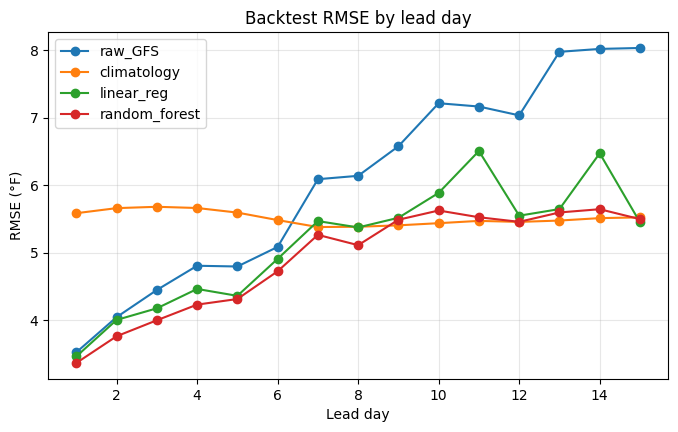


Backtest runs: 80
RF beats raw GFS in 90% of runs
LR beats raw GFS in 82% of runs
RF beats LR      in 65% of runs


/tmp/ipykernel_4968/1737617885.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_run = scored.groupby('run_time').apply(lambda r: pd.Series(


In [ ]:
MODELS = {'raw_GFS': 'forecast_temp', 'climatology': 'climo', 'linear_reg': 'lr_pred', 'random_forest': 'rf_pred'}

def score_table(d, by):
    return d.groupby(by).apply(lambda t: pd.Series(
        {name: rmse(t['actual_temp'], t[col]) for name, col in MODELS.items()})).round(3)

print('All folds pooled:', {name: round(rmse(scored['actual_temp'], scored[col]), 3) for name, col in MODELS.items()})
print('\nBy fold:');     print(score_table(scored, 'fold').to_string())
by_lead = score_table(scored, 'lead_day')
print('\nBy lead day:'); print(by_lead.to_string())

by_lead.plot(marker='o', figsize=(8, 4.5))
plt.xlabel('Lead day'); plt.ylabel('RMSE (°F)')
plt.title('Backtest RMSE by lead day'); plt.grid(alpha=0.3); plt.show()

per_run = scored.groupby('run_time').apply(lambda r: pd.Series(
    {name: rmse(r['actual_temp'], r[col]) for name, col in MODELS.items()}))
print('\nBacktest runs:', len(per_run))
print('RF beats raw GFS in %.0f%% of runs' % (100 * (per_run['random_forest'] < per_run['raw_GFS']).mean()))
print('LR beats raw GFS in %.0f%% of runs' % (100 * (per_run['linear_reg'] < per_run['raw_GFS']).mean()))
print('RF beats LR      in %.0f%% of runs' % (100 * (per_run['random_forest'] < per_run['linear_reg']).mean()))

### Random Forest Test Sep 17 – Sep 30

What the forest relies on:
fc_anom          0.634
lead_hours       0.137
wind_cos         0.073
wind_sin         0.039
hour_cos         0.032
wind_speed       0.026
cloud_cover      0.022
hour_sin         0.015
precipitation    0.012
hour_sin2        0.006
hour_cos2        0.003
                     time  raw_gfs_temp  climatology_temp  lr_predicted_temp  \
63370 2026-09-17 00:00:00          70.6             68.63              72.55   
63371 2026-09-17 01:00:00          69.5             67.90              71.26   
63372 2026-09-17 02:00:00          68.0             67.17              69.68   
63373 2026-09-17 03:00:00          66.8             66.41              68.43   
63374 2026-09-17 04:00:00          65.9             65.69              67.50   

       rf_predicted_temp  
63370              72.29  
63371              71.19  
63372              69.87  
63373              69.07  
63374              68.15  


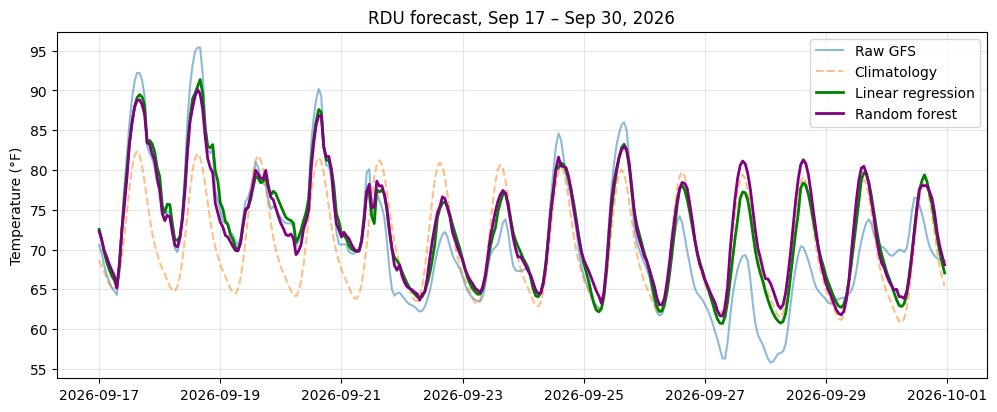

In [ ]:
final_rf = make_rf(BEST_LEAF).fit(model_df[RF_FEATURES], model_df['target_anom'])

importance = pd.Series(final_rf.feature_importances_, index=RF_FEATURES).sort_values(ascending=False)
print('What the forest relies on:'); print(importance.round(3).to_string())

future['rf_predicted_temp'] = final_rf.predict(future[RF_FEATURES]) + future['climo']
out['rf_predicted_temp'] = future['rf_predicted_temp'].round(2).values
out = out.rename(columns={'predicted_temp': 'lr_predicted_temp'})
out.to_csv('predictions_sep17_30.csv', index=False)
print(out.head())

plt.figure(figsize=(12, 4.5))
plt.plot(out['time'], out['raw_gfs_temp'], label='Raw GFS', alpha=0.5)
plt.plot(out['time'], out['climatology_temp'], label='Climatology', alpha=0.5, linestyle='--')
plt.plot(out['time'], out['lr_predicted_temp'], label='Linear regression', linewidth=2, color='green')
plt.plot(out['time'], out['rf_predicted_temp'], label='Random forest', linewidth=2, color='purple')
plt.ylabel('Temperature (°F)'); plt.title('RDU forecast, Sep 17 – Sep 30, 2026')
plt.legend(); plt.grid(alpha=0.3); plt.show()

## Test & Score Models

Fetched observations through 2026-10-02 00:00:00
Hours compared: 336 | 2026-09-17 00:00:00 -> 2026-09-30 23:00:00
linear_reg     RMSE 6.88°F | MAE 5.25°F | bias +1.10°F
random_forest  RMSE 7.00°F | MAE 5.42°F | bias +1.35°F
raw_GFS        RMSE 7.84°F | MAE 6.24°F | bias -0.34°F
climatology    RMSE 7.61°F | MAE 6.34°F | bias -0.83°F
            linear_reg  random_forest  raw_GFS  climatology         winner
time                                                                      
2026-09-17        2.05           2.43     1.62         7.30        raw_GFS
2026-09-18        3.31           3.46     3.17         9.89        raw_GFS
2026-09-19        4.85           4.80     4.66         7.29        raw_GFS
2026-09-20        4.04           4.01     4.18         7.61  random_forest
2026-09-21        9.13           8.69    10.32         9.51  random_forest
2026-09-22        5.54           4.99     7.46         3.57  random_forest
2026-09-23        9.18           9.46     6.76        10.68       

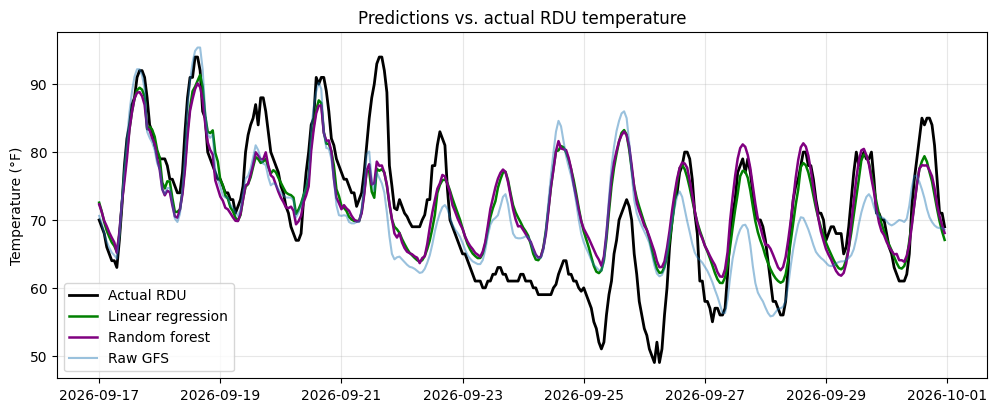

In [ ]:
score_actual = actual[['time', 'tmpf']].copy()
try:
    url = ("https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"
           "?station=RDU&data=tmpf"
           "&year1=2026&month1=9&day1=16&year2=2026&month2=10&day2=2"
           "&tz=America%2FNew_York&format=onlycomma&latlon=no&missing=M&trace=T"
           "&direct=no&report_type=3&report_type=4")
    recent = pd.read_csv(url).rename(columns={'valid': 'time'})
    recent['time'] = pd.to_datetime(recent['time']).dt.round('h')
    recent['tmpf'] = pd.to_numeric(recent['tmpf'], errors='coerce')
    recent = recent.dropna(subset=['tmpf'])
    split_at = pd.Timestamp('2026-09-16 12:00')
    score_actual = pd.concat([score_actual[score_actual['time'] < split_at],
                              recent.loc[recent['time'] >= split_at, ['time', 'tmpf']]], ignore_index=True)
    print('Fetched observations through', recent['time'].max())
except Exception as e:
    print('Could not fetch recent observations, using the actuals file only:', str(e)[:80])

actual_target = (score_actual.groupby('time', as_index=False)['tmpf'].mean()
                             .rename(columns={'tmpf': 'actual_temp'}))
compare = out.merge(actual_target, on='time', how='inner')
compare.to_csv('predictions_vs_actual.csv', index=False)

COLS = {'linear_reg': 'lr_predicted_temp', 'random_forest': 'rf_predicted_temp',
        'raw_GFS': 'raw_gfs_temp', 'climatology': 'climatology_temp'}
print('Hours compared:', len(compare), '|', compare['time'].min(), '->', compare['time'].max())
for name, col in COLS.items():
    err = compare[col] - compare['actual_temp']
    print('%-14s RMSE %.2f°F | MAE %.2f°F | bias %+.2f°F'
          % (name, rmse(compare['actual_temp'], compare[col]), err.abs().mean(), err.mean()))

daily = compare.groupby(compare['time'].dt.date).apply(lambda d: pd.Series(
    {name: rmse(d['actual_temp'], d[col]) for name, col in COLS.items()})).round(2)
daily['winner'] = daily[['linear_reg', 'random_forest', 'raw_GFS']].idxmin(axis=1)
print(daily.to_string()); print(daily['winner'].value_counts().to_string())

plt.figure(figsize=(12, 4.5))
plt.plot(compare['time'], compare['actual_temp'], color='black', linewidth=2, label='Actual RDU')
plt.plot(compare['time'], compare['lr_predicted_temp'], color='green', linewidth=1.8, label='Linear regression')
plt.plot(compare['time'], compare['rf_predicted_temp'], color='purple', linewidth=1.8, label='Random forest')
plt.plot(compare['time'], compare['raw_gfs_temp'], alpha=0.45, label='Raw GFS')
plt.ylabel('Temperature (°F)'); plt.title('Predictions vs. actual RDU temperature')
plt.legend(); plt.grid(alpha=0.3); plt.show()